In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision

# **Parameter initialization and data preparation**

In [2]:
# Parameters
batch_size = 8
num_epochs = 10
device = 'cuda:0'
num_classes = 10
noise_std = 0.5

# Load dataset
transform = torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
     torchvision.transforms.Normalize((0.5), (0.5))])

trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
valset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)

print(trainset)

# Create dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                         shuffle=False)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=0.5, std=0.5)
           )


In [3]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize to show images correctly
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

torch.Size([8, 1, 28, 28])


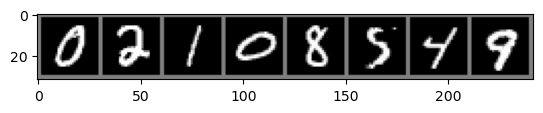

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2553453..2.0626888].


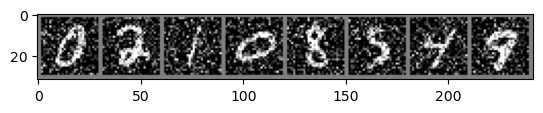

    0     2     1     0     8     5     4     9


In [4]:
# Print some samples of dataset as a sanity check

# Get some random training images
dataiter = iter(trainloader)
example_images, example_labels = next(dataiter)

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))

noisy_examples = example_images + (noise_std**0.5)*torch.randn_like(example_images)
imshow(torchvision.utils.make_grid(noisy_examples))

# Print labels
print(' '.join('%5s' % example_labels[j].item() for j in range(batch_size)))

# **Define Models**

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 4, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.pool_same = nn.MaxPool2d(2, 2, padding=1)
        self.conv2 = nn.Conv2d(4, 8, 3, padding=1)
        self.conv3 = nn.Conv2d(8, 16, 3, padding=1)
        self.conv4 = nn.Conv2d(16, 16, 3, padding=1)
        self.upsample = nn.Upsample(scale_factor=(2,2))
        self.conv5 = nn.Conv2d(16, 8, 3, padding=1)
        self.conv6 = nn.Conv2d(8, 4, 3)
        self.conv7 = nn.Conv2d(4, 1, 3, padding=1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool_same(F.relu(self.conv3(x)))

        x = self.upsample(F.relu(self.conv4(x)))
        x = self.upsample(F.relu(self.conv5(x)))
        x = self.upsample(F.relu(self.conv6(x)))
        x = self.conv7(x)
        return x

In [6]:
class AutoencoderDense(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_features, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, input_features)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        x = x.view(-1, 1, 28, 28)
        return x

# **Make a training loop**

In [7]:
def compute_run_acc(logits, labels):
    _, pred = torch.max(logits.data, 1)
    return (pred == labels).sum().item()

In [8]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [9]:
# Instantiate model and optimizer

model = Autoencoder(1).to(device)
# model = AutoencoderDense(784).to(device)

print("Number of trainable parameters: {}".format(count_parameters(model)))

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

tr_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

for epoch_nr in range(num_epochs):

    print("Epoch {}:".format(epoch_nr))

    # Train model
    running_loss = 0.0
    for batch_data, _ in trainloader:

        # Put data on device
        batch_data = batch_data.to(device)
        noisy_data = batch_data + (noise_std**0.5)*torch.randn_like(batch_data)

        # Predict and get loss
        output = model(noisy_data)
        loss = criterion(output, batch_data)

        # Update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
      
    # Print results
    tr_loss = running_loss/len(trainloader.dataset)
    print('>> TRAIN: Epoch {} completed | tr_loss: {:.4f}'.format(
        epoch_nr, running_loss/len(trainloader.dataset)))
    
    # Get validation results
    running_loss = 0
    with torch.no_grad():
        for batch_data, _ in valloader:
            batch_data = batch_data.to(device)
            noisy_data = batch_data + (noise_std**0.5)*torch.randn_like(batch_data)
            output = model(noisy_data)
            running_loss += criterion(output, batch_data).item()

    val_loss = running_loss/len(valloader.dataset)
    print('>> VALIDATION: Epoch {} | val_loss: {:.4f}'.format(epoch_nr, val_loss))

    tr_losses[epoch_nr] = tr_loss
    val_losses[epoch_nr] = val_loss

print('Training finished')

Number of trainable parameters: 5313
Epoch 0:
>> TRAIN: Epoch 0 completed | tr_loss: 0.0169
>> VALIDATION: Epoch 0 | val_loss: 0.0127
Epoch 1:
>> TRAIN: Epoch 1 completed | tr_loss: 0.0120
>> VALIDATION: Epoch 1 | val_loss: 0.0114
Epoch 2:
>> TRAIN: Epoch 2 completed | tr_loss: 0.0113
>> VALIDATION: Epoch 2 | val_loss: 0.0109
Epoch 3:
>> TRAIN: Epoch 3 completed | tr_loss: 0.0111
>> VALIDATION: Epoch 3 | val_loss: 0.0107
Epoch 4:
>> TRAIN: Epoch 4 completed | tr_loss: 0.0109
>> VALIDATION: Epoch 4 | val_loss: 0.0107
Epoch 5:
>> TRAIN: Epoch 5 completed | tr_loss: 0.0108
>> VALIDATION: Epoch 5 | val_loss: 0.0104
Epoch 6:
>> TRAIN: Epoch 6 completed | tr_loss: 0.0098
>> VALIDATION: Epoch 6 | val_loss: 0.0094
Epoch 7:
>> TRAIN: Epoch 7 completed | tr_loss: 0.0095
>> VALIDATION: Epoch 7 | val_loss: 0.0092
Epoch 8:
>> TRAIN: Epoch 8 completed | tr_loss: 0.0094
>> VALIDATION: Epoch 8 | val_loss: 0.0093
Epoch 9:
>> TRAIN: Epoch 9 completed | tr_loss: 0.0093
>> VALIDATION: Epoch 9 | val_loss: 

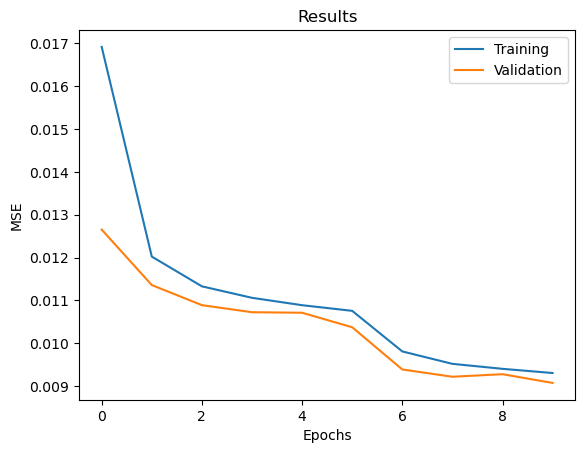

In [10]:
plt.figure()
plt.plot(tr_losses, label='Training')
plt.plot(val_losses, label='Validation')
plt.title('Results')
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [ ]:
# Print some samples of dataset as a sanity check

# Get some random validation images
dataiter = iter(valloader)
example_images, _ = next(dataiter)

print(example_images.shape)

# Show images
imshow(torchvision.utils.make_grid(example_images))
noisy_data = example_images + (noise_std**0.5)*torch.randn_like(example_images)
imshow(torchvision.utils.make_grid(noisy_data))
preds = model(noisy_data.to(device))
imshow(torchvision.utils.make_grid(preds.cpu()))
# Print labels
print(' '.join('%5s' % example_labels[j].item() for j in range(batch_size)))

AttributeError: '_SingleProcessDataLoaderIter' object has no attribute 'next'